# Программирование на Python, БИ

## НИУ ВШЭ, 2025-26 учебный год

# Семинар 19. A/B-тестирования


### Идея A/B-тестирования

Основные поинты, которые можно выделить по A/B-тестированию, заключаются в следующем:

- Метод маркетингового исследования
- Набор пользователей разбивается на контрольную и тестовую группы
- В тестовой группе вносится некоторое изменение
- Эффект от изменений оценивается сравнением целевых метрик в
группах


### Дизайн эксперимента

Когда вы создаёте свой эксперимент в рамках A/B-тестирования, необходимо придерживаться следующего пайплайна:

- Сфомировать гипотезу
- Зафиксировать цели и метрики эксперимента
- Исключить внешние факторы
- Оценить необходимый объем выборки и время проведения
эксперимента
- Сформировать выборки и запустить A/В тест
- Оценить эффект


Оценка эффекта — последний и крайне важный этап в рамках A/B-тестирований. Наша разница случайна или всё-таки не случайна?

#### Вопрос

Для распределений данных в A/B-тестировании — в какой дисперсии мы заинтересованы: в большой или маленькой?

<img src=https://annalyzin.files.wordpress.com/2017/07/ab-stdev.png width="800"/>

###  Выборочное среднее

Чаще всего в рамках эксперимента нам необходимо работать с каким-либо средним показателем. В связи с этим вспомним понятие выборочного среднего:

- основанное на выборке приближение теоретического среднего для распределения
- дисперсия оценки зависит от числа наблюдений

При этом, если взять три случайные выборки из одной совокупности, они благополучно дают три разные величины среднего и стандартного отклонения.



Таким образом, как связаны дисперсия выборочного среднего и размер выборки?

- в процессе эксперимента получаем N значений
- оцениваем среднее полученных значений
- повторяем эксперимент M раз
- получаем M оценок средних
- дисперсия этих оценок зависит от числа наблюдений в эксперименте

###  Пример задачи

<img src=https://cloud.netlifyusercontent.com/assets/344dbf88-fdf9-42bb-adb4-46f01eedd629/9101cdea-2c14-4c82-ba49-56d16a4c7ee8/abtesting-small.gif width="500"/>

Предположим, что мы хотим провести редизайн сайта интернет-магазина и наша задача оценить какой из макетов наиболее "кликабельный".

Для этого мы будем оценивать показатель CTR (click-through rate) у двух групп пользователей. Первым (группа A) будем показывать старый дизайн, а вторым (группе B) — новый.

В данной задаче мы имеем дело с последовательностью независимых случайных событий: "пользователь кликнул/не кликнул". Совокупность таких событий для $n = 1$ (одного проведенного эксперимента) подчинена распределению Бернулли, а при $n > 1$ — биномиальному распределению, т.е. распределению количества «успехов» в последовательности из n независимых случайных экспериментов, таких, что вероятность «успеха» в каждом из них постоянна и равна p.

#### Вопрос

А как связано биномиальное распределение и нормальное?

### Связь биномиального распределения с нормальным

In [ ]:
from scipy import stats as st

from numpy.random import binomial
from numpy.random import normal

import numpy as np
import matplotlib.pyplot as plt

from scipy.stats import ttest_ind, ttest_rel
from scipy.stats import t, norm


Сгенерируем некоторую выборку данных из исходного биномиального распределения

In [ ]:
np.random.seed(2111)

In [ ]:
P = 0.1  # convertion rate
N = 20   # sample size

In [ ]:
sample = binomial(1, P, N)
print('sample: %s' % sample)
print('mean: %s' % np.mean(sample))

sample: [0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 0 1 0]
mean: 0.05


Оценим параметры имеющегося у нас биномиального распределения

In [ ]:
M = 1000  # number of experiments

In [ ]:
experiments = binomial(1, P, (M, N))
print('experiemnts shape: %sх%s' % experiments.shape)

experiemnts shape: 1000х20


In [ ]:
# оценим среднее для каждого эксперимента
means = np.mean(experiments, axis=1)
means

array([0.  , 0.2 , 0.  , 0.15, 0.05, 0.  , 0.15, 0.05, 0.1 , 0.05, 0.1 ,
       0.  , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.05, 0.15, 0.15, 0.15, 0.1 ,
       0.  , 0.1 , 0.05, 0.15, 0.15, 0.15, 0.1 , 0.1 , 0.25, 0.15, 0.15,
       0.  , 0.15, 0.05, 0.15, 0.1 , 0.  , 0.05, 0.2 , 0.  , 0.1 , 0.05,
       0.1 , 0.1 , 0.15, 0.05, 0.2 , 0.15, 0.  , 0.05, 0.1 , 0.2 , 0.1 ,
       0.1 , 0.1 , 0.15, 0.15, 0.05, 0.1 , 0.1 , 0.1 , 0.2 , 0.15, 0.15,
       0.  , 0.1 , 0.15, 0.  , 0.05, 0.  , 0.2 , 0.05, 0.15, 0.  , 0.05,
       0.2 , 0.15, 0.15, 0.1 , 0.15, 0.05, 0.25, 0.1 , 0.05, 0.15, 0.1 ,
       0.1 , 0.  , 0.05, 0.1 , 0.05, 0.25, 0.05, 0.25, 0.15, 0.2 , 0.05,
       0.05, 0.05, 0.15, 0.1 , 0.15, 0.1 , 0.  , 0.1 , 0.1 , 0.1 , 0.25,
       0.05, 0.1 , 0.2 , 0.1 , 0.1 , 0.2 , 0.05, 0.1 , 0.25, 0.2 , 0.15,
       0.1 , 0.05, 0.05, 0.15, 0.2 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 , 0.1 ,
       0.1 , 0.25, 0.  , 0.  , 0.2 , 0.1 , 0.2 , 0.1 , 0.2 , 0.1 , 0.1 ,
       0.  , 0.2 , 0.15, 0.15, 0.1 , 0.1 , 0.1 , 0.

In [ ]:
# оценим дисперсию средних
means_std = np.var(means)
means_std

np.float64(0.00449639)

Оценим зависимость дисперсии от числа наблюдений

In [ ]:
# построим график зависимости дисперсии от числа наблюдений
means_stds = []
k = np.arange(20, 2500, 20)
for i in k:
  experiments = binomial(1, P, (i, N))
  means = np.mean(experiments, axis=1)
  means_stds.append(np.var(means))

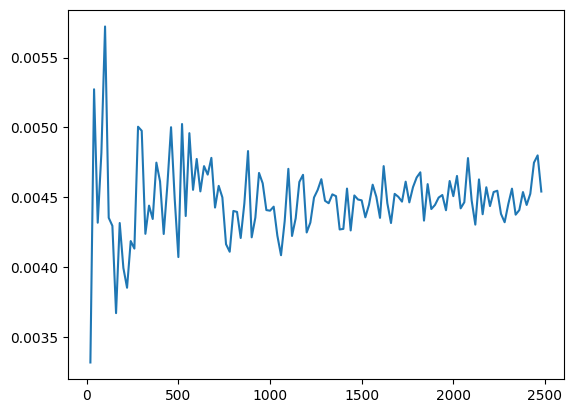

In [ ]:
plt.plot(k, means_stds)
plt.show()

#### Вопрос

Какие выводы можно сделать? Уменьшается ли дисперсия?

Итак, теперь у нас есть всё для того, чтобы понять, как осуществляется интересующая нас аппроксимация.

Если n достаточно велико, то в этом случае разумное приближение $\mathrm{Bin} (n, p)$ дается нормальным распределением:  N(np, np (1-p)) — знакомая нам ИТМЛ (неформальная аббревиатура для ЦПТ).

<img src=https://upload.wikimedia.org/wikipedia/commons/thumb/b/b7/Binomial_Distribution.svg/1920px-Binomial_Distribution.svg.png width="500"/>

Сравним распределение средних с нормальным

$\mu = p$

$\sigma = \sqrt{\frac{p(1-p)}{n}}$

In [ ]:
mean = P
std = np.sqrt(P * (1 - P) / N)

In [ ]:
# сравним распределение с нормальным

normal_distr = normal(loc=P, scale = std, size=N)
print('norm_mean: %.5f' % np.mean(normal_distr), 'bin_mean: %.5f' % mean)
print('norm_std: %.5f' % np.std(normal_distr), 'bin_std: %.5f' % std)

norm_mean: 0.09558 bin_mean: 0.10000
norm_std: 0.05842 bin_std: 0.06708


Мы проверили на симуляции, что среднее и стандартное отклонение распределения средних из биномиального почти совпадают с соответствующими параметрами нормального распределения. Значит, нормальная аппроксимация корректна, и CTR можно анализировать через нормальную модель (ЦПТ).

### Зависимость дисперсии среднего от числа примеров в эксперименте

Центральная предельная теорема — ключевой закон, применяющийся нами в этом месте. Если забыли или не уверены, вспомнить ЦПТ можно, например, [тут](https://en.wikipedia.org/wiki/Central_limit_theorem). Также — хорошее [видео](https://www.youtube.com/watch?v=jvoxEYmQHNM).



<img src=https://i.ibb.co/0ckyS0F/Screenshot-2020-02-27-at-07-59-01.png width="800"/>


Зададим дисперсию в популяции

In [ ]:
POPULATION_STD = 10

In [ ]:
# Функция генерации данных экспериментов
def gen_expiremnts(mean=0,
                   n_samples=10,
                   n_experiements=500):
    return np.random.normal(loc=mean,
                            scale=POPULATION_STD,
                            size=(n_experiements, n_samples))

In [ ]:
gen_expiremnts(mean=0,
                   n_samples=2,
                   n_experiements=4)

array([[ -9.64109118,   3.95630215],
       [-15.96908621,   4.35954734],
       [ 16.55437048,  -6.78625219],
       [-10.04251514,   1.04494256]])

Проводим 500 экспериментов с разным числом наблюдений

In [ ]:
sample_mean_std = []
n_samples = list(range(10, 110, 10))
for n in n_samples:
    data = gen_expiremnts(n_experiements=500, n_samples=n)
    means = np.mean(data, axis=1)         # вычисляем среднее для каждого эксперимента
    sample_mean_std.append(np.std(means)) # сохраняем дисперсию средних

In [ ]:
sample_mean_std

[np.float64(3.0437729648455276),
 np.float64(2.387829417804819),
 np.float64(1.7738497935403852),
 np.float64(1.6479401764777148),
 np.float64(1.388886586120151),
 np.float64(1.2932205647495154),
 np.float64(1.2183454735633914),
 np.float64(1.1352766318773742),
 np.float64(1.0700943645567857),
 np.float64(1.04603445844117)]

Вычисляем зависимость дисперсии средних от числа наблюдений по ЦПТ:

In [ ]:
sample_mean_std_clt = POPULATION_STD / np.sqrt(n_samples)

Теперь сравниваем с теоретическими значениями по ЦПТ

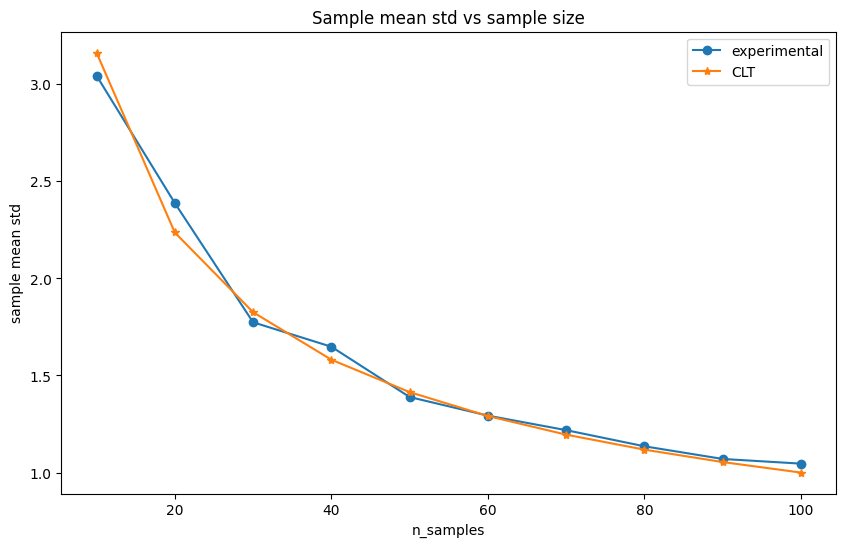

In [ ]:
plt.figure(figsize=(10, 6))
plt.plot(n_samples, sample_mean_std, '-o',
         n_samples, sample_mean_std_clt, '-*')
plt.xlabel('n_samples')
plt.ylabel('sample mean std')
plt.legend(['experimental', 'CLT'])
plt.title('Sample mean std vs sample size');

Кажется, работает! :)

### Z-test

Z-test — это еще один очень удобный статистический тест, который применяется для проверки гипотез при использовании ЦПТ. Подробно о нём прочитать можно, например, [тут](https://en.wikipedia.org/wiki/Z-test).

На самом деле, Z-тест — это любой статистический тест, для которого распределение тестовой статистики в соответствии с нулевой гипотезой может быть аппроксимировано нормальным распределением. Из-за центральной предельной теоремы многие тестовые статистические данные как раз и распределяются примерно нормально для больших выборок. Для каждого уровня значимости в доверительном интервале Z-критерий имеет одно критическое значение, что делает его более удобным, чем t-критерий Стьюдента, который имеет отдельные и разные критические значения для каждого размера выборки. Поэтому многие статистические тесты могут быть удобно выполнены как приблизительные Z-тесты, если размер выборки большой.

In [ ]:
MEAN_A = 10           # среднее значение в эксперименте A
MEAN_B = 12           # среднее значение в эксперименте B
POPULATION_STD = 10.  # задаем дисперсию в популяции
N_SAMPLES = 250       # число наблюдений в каждом из экспериментов

In [ ]:
# Семплируем данные экспериментов
X_a = np.random.normal(loc=MEAN_A,
                       scale=POPULATION_STD,
                       size=N_SAMPLES)

X_b = np.random.normal(loc=MEAN_B,
                       scale=POPULATION_STD,
                       size=N_SAMPLES)

X_mean_a = np.mean(X_a)
X_mean_b = np.mean(X_b)

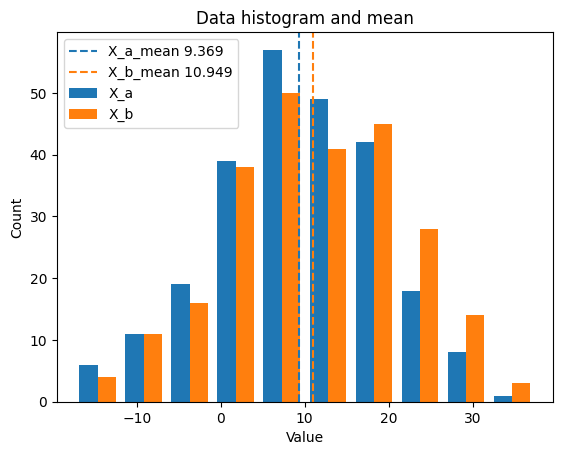

In [ ]:
# Визуализируем данные экспериментов
plt.hist([X_a, X_b])
plt.axvline(x=X_mean_a, color='C0', linestyle='--')
plt.axvline(x=X_mean_b, color='C1', linestyle='--')
plt.ylabel('Count')
plt.xlabel('Value')
plt.title('Data histogram and mean')
plt.legend(['X_a_mean %.3f' % X_mean_a,
            'X_b_mean %.3f' % X_mean_b,
            'X_a', 'X_b']);

In [ ]:
# Оцениваем стандартную ошибку
se_a = se_b = POPULATION_STD / np.sqrt(N_SAMPLES)
se_ab = np.sqrt(se_a ** 2 + se_b ** 2)  # стандартная ошибка разности

In [ ]:
diff = (X_mean_b - X_mean_a)       # разность средних значений двух экспериментов
z = diff / se_ab                   # вычисляем z-статистику
z_quantile = st.norm.cdf(z)        # вычисляем квантиль z-статистики
print('diff=%.2f z=%.2f q=%.2f' % (diff, z, z_quantile))

diff=1.58 z=1.77 q=0.96


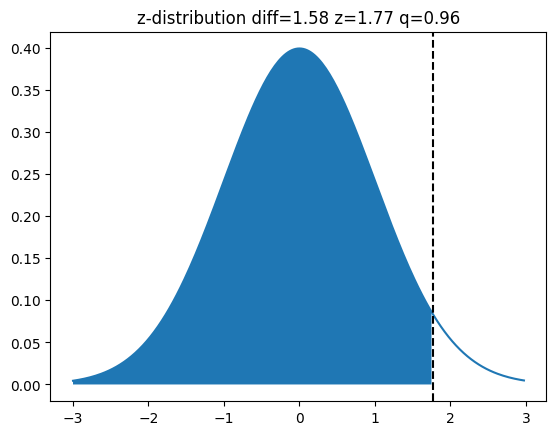

In [ ]:
# Визуализируем z-распределение
x = np.arange(-3, 3, 0.025)
plt.plot(x, st.norm.pdf(x))
plt.axvline(z, color='k', linestyle='--')
plt.fill_between(x, st.norm.pdf(x), where=x<z)
plt.title('z-distribution diff=%.2f z=%.2f q=%.2f' % (diff, z, z_quantile));

Что можно сказать о результатах?

q = 1-(p-value),то есть в данном случае p-value очень близко к 0, то есть нулевую гипотезу конечно же отклоняем. НО важно помнить, что p-value в z-тесте считается из z-статистики!!! (а для расчета p-value используем таблицу стандартного нормального распределения).

Кроме того, из графика видим, что наша z-cтатистика где-то далеко в хвосте, так что опять таки точно отклоняем нулевую гипотезу (вывод о результате z-теста можно сделать и не считая p-value, если полученное z > z критического, то отклоняем нулевую, в свою очередь z-критеческие - это фиксированные значения в зависимости от уровня значимости)

### Проведение эксперимента (A/B тест)

Итак, мы готовы к непосредственному проведению эксперимента

Сгенерируем семплы

In [ ]:
P1 = 0.1
P2 = 0.11
N1 = 100
N2 = 100

In [ ]:
sample1 = binomial(1, P1, N1)
sample2 = binomial(1, P2, N2)

In [ ]:
mean1 = np.mean(sample1)
mean2 = np.mean(sample2)
diff = mean2 - mean1
print('mean1: %s' % mean1)
print('mean2: %s' % mean2)
print('mean1 - mean2: %s' % diff)

mean1: 0.12
mean2: 0.1
mean1 - mean2: -0.01999999999999999


Оценим выборочное (pooled) среднее и дисперсию

In [ ]:
P_pool = (np.sum(sample1 == 1) + np.sum(sample2 == 1)) / (N1 + N2)
std_pool = np.sqrt(P_pool * (1 - P_pool) / (N1 + N2))

In [ ]:
confidence = 0.975
z = st.norm.ppf(confidence)
margin = z * std_pool
print('z: %s' % z)

z: 1.959963984540054


0.975, так как двустороння гипотеза, а мы ищем значение z, левее которого лежит 97.5% распределения.

margin - это ширина доверительного интервала

diff - фактическая разница средних

Если  |diff| > margi, то разница значима (нулевую гипотезу отклоняем).
Если нет, то и оснований для отклонения нулевой гипотезы нет.

Случайно ли различие в средних?

In [ ]:
print('margin: %s' % margin)
print('diff: %s' % diff)
print('Are they different (diff > margin)? -> %s' % (abs(diff) > margin))

margin: 0.04336351107474779
diff: -0.01999999999999999
Are they different (diff > margin)? -> False


**ЗАДАЧА**

Петя нанимает себе в закусочную нового управляющего, который говорит, что он значительно повысил эффективность официантов. По его словам теперь обслуживание в зале стало гораздо быстрее, чем было до его прихода, управляющий просит выплатить ему премию. Петя принес еам результаты теста в датасете ab_test_results_waiters.csv. Нам надо проанализировать данные и дать Пете рекомендацию на основе полученных выводов.

In [ ]:
import pandas as pd
import numpy as np

df = pd.read_csv('ab_test_results_waiters.csv')
df

,Group,WaitingTime
0,A,42.360522
1,A,27.966232
2,A,26.127363
3,A,26.127671
4,A,75.000000
...,...,...
175,B,26.488839
176,B,10.536025
177,B,13.461588
178,B,20.868366


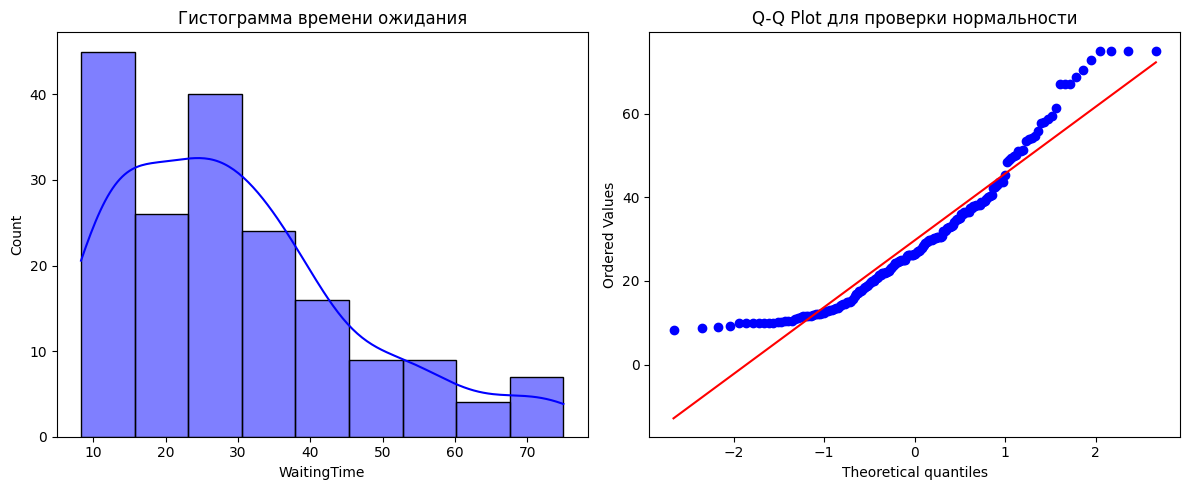

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import scipy.stats as stats

plt.figure(figsize=(12, 5))

plt.subplot(1, 2, 1)
sns.histplot(df['WaitingTime'], kde=True, color='blue')
plt.title('Гистограмма времени ожидания')

plt.subplot(1, 2, 2)
stats.probplot(df['WaitingTime'], dist="norm", plot=plt)
plt.title('Q-Q Plot для проверки нормальности')

plt.tight_layout()
plt.show()

Как мы видим, данные распределены не нормально, поэтому будем использовать тест для независимых выборок при том, что данные не подчиняются закону нормального распрделения. Будем использовать **тест Манна-Уитни**.

H0(нулевая гипотеза) -  среднее время ожидания до и после прихода управляющего одинаково

H1(альтернативная гипотеза) - среднее время ожидания после прихода управляющего отличается о среднего времени до его прихода

In [ ]:
from scipy.stats import mannwhitneyu

group_before = df[df['Group'] == 'A']['WaitingTime']
group_after = df[df['Group'] == 'B']['WaitingTime']

stat, p_value = mannwhitneyu(group_before, group_after)

print(f"Статистика теста: {stat}, p-значение: {p_value}")

Статистика теста: 5114.0, p-значение: 0.002344749226243769


In [ ]:
print(group_before.mean())
print(group_after.mean())

33.55270479305549
25.8653796433333


**Вывод:** p-value<<0.05 значит увренно отклоняем нулевую гипотезу, то есть различия времени ожидания между группами А и В статистически значимы. По среднему времени ожидания мы видим, что оно скоратилось, то есть управляющий действительно повлиял на это, и ему надо выписать премию.

**ЗАДАЧА (для самостоятельного решения)**

У крупного онлайн-кинотеатра появился новый промо-баннер на сайте, который показывает пользователям подборку трейлеров фильмов по их интересам. Команда провела А/В-тестирование (выборке А - показывали старый баннер, а выборке В - новый). Результаты тестирования находятся в датасете ab_test_watch_time.csv. Помогите им разобраться - увеличивает ли новый баннер среднее время просмотра трейлеров?

In [ ]:
df = pd.read_csv('ab_test_watch_time.csv')

print(df.shape)
df.head()

(300, 2)


,Group,watch_time
0,A,48.1
1,B,56.0
2,A,49.7
3,A,38.3
4,A,61.4


Нужно проверить нормальность распредления - Q-Q плот либо тест Шапиро-Уилка (тест Шапиро показал бы, что нет оснований отклонять нулевую гипотезу, то есть распределение не нормальнео => стоит использовать тест Манна-Уитни; в данном случае подходит и т-тест и Манна-Уитни)

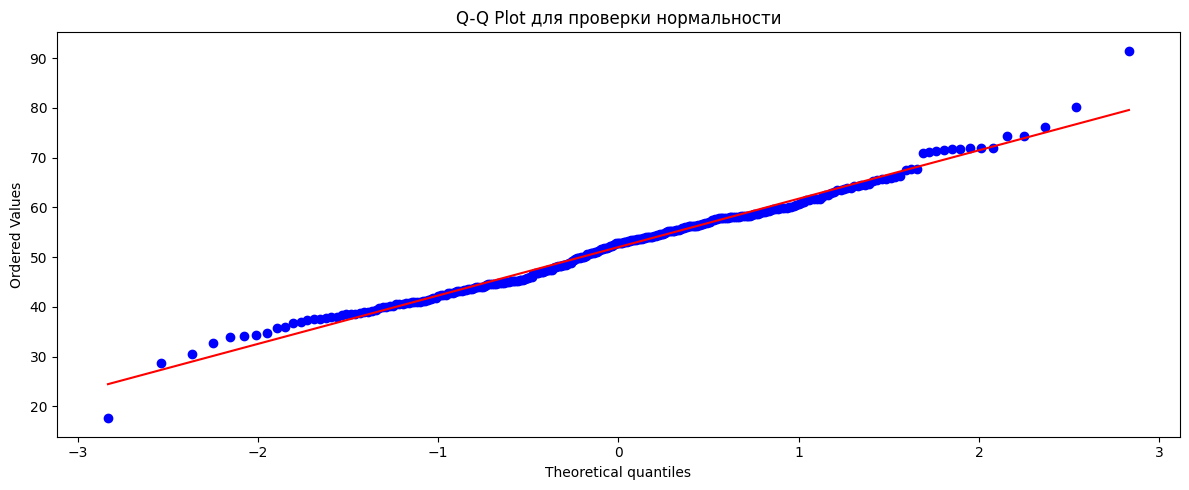

In [ ]:
plt.figure(figsize=(12, 5))

stats.probplot(df['watch_time'], dist="norm", plot=plt)
plt.title('Q-Q Plot для проверки нормальности')

plt.tight_layout()
plt.show()

In [ ]:
from scipy.stats import ttest_ind

group_A = df[df["Group"] == "A"]["watch_time"]
group_B = df[df["Group"] == "B"]["watch_time"]

t_stat, p_value = ttest_ind(group_A, group_B, equal_var=True)

print("T-statistic:", t_stat)
print("P-value:", p_value)


T-statistic: -2.3093881010804806
P-value: 0.021605697872522873


P-value < 0.05 => оклоянем нулевую гипотезу

T-statistic < 0 => среднее время просмотра в выборке А меньше, чем в выборке В, то есть новый баннер увеличивает среднее время просмотра трейлеров, и эта разница статистически значима!